In [392]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import fft

Variable initialization

In [393]:
M = 32 # signal dimension
N = 2 * M # number of atoms in the expansion


C = np.zeros((M, M)) # matrix containing the standard basis (a kronecker delta in each column)
DCT = np.zeros((M, M)) #matrix containing the DCT basis (a DCT function in each column)

Generate the 1D-DCT basis

In [394]:
C_zero = np.sqrt(1/M)
C_k = np.sqrt(2/M)

for i in range(M):
    DCT[:, i] = C_zero * np.ones(M) if i == 0 else C_k * np.cos(i*np.pi*(np.arange(M)+0.5)/M)
    DCT[:,i] = DCT[:,i] / np.linalg.norm(DCT[:,i])

Generating the 1-D canonical basis

In [395]:
for i in range(M):
    C[i, i] = 1


Define the dictionary $D = [DCT, C]$

Text(0.5, 1.0, 'Our dictionary M = 32, N = 64')

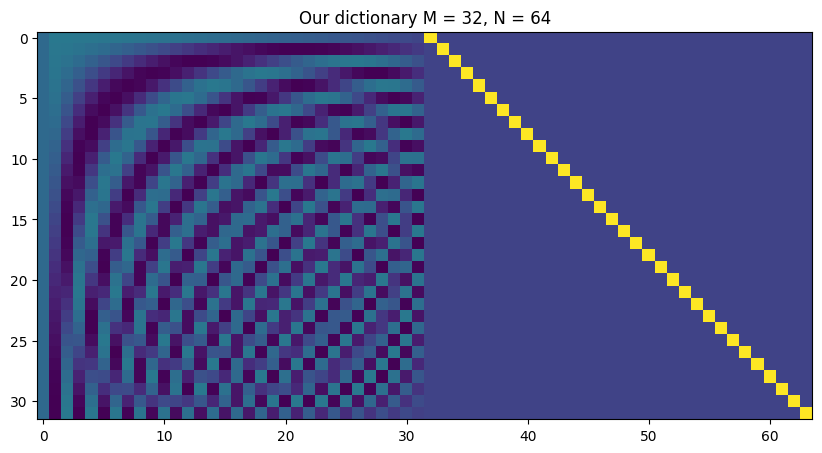

In [396]:
D = np.hstack((DCT, C))

plt.figure(figsize=(10,10))
plt.imshow(D)
plt.title(f'Our dictionary M = {M}, N = {N}')

Generate a signal that is sparse w.r.t. $D$
-----------------------------------------
To this purpose add a spike to the sum of few DCT atoms, i.e., add a spike to $\mathbf{s}$ that is sparse w.r.t. $C$. Bear in mind that the spike is to be considered a signal to be reconstructed, rather than noise

In [397]:
L = 4
sigma_noise = 0.2

Randomly define the coefficients of a sparse representation w.r.t. $DCT$ (make sure the nonzero coefficients are sufficiently large)

In [398]:
x0 = np.zeros(N)
indices = np.random.choice(N, L, replace=False)
x0[indices] = np.random.rand(L)*10

Choose spike location

In [399]:
spikeLocation = np.random.choice(N)
x0[spikeLocation] = 500

Synthetize the corresponding signal in the signal domain and add noise


In [400]:
s0 = D @ x0
s = s0 + sigma_noise * np.random.randn(M)

Plot the sparse signal

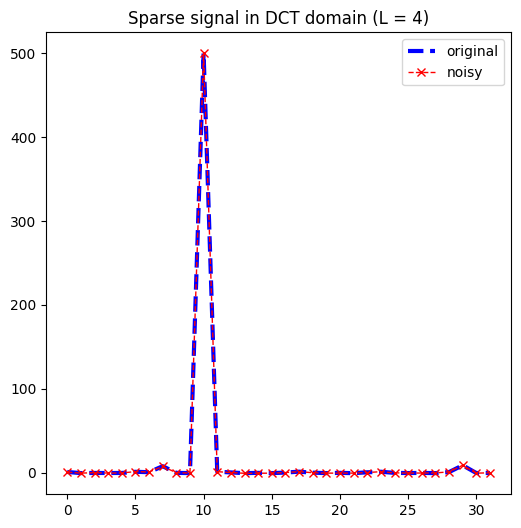

In [401]:
LN_WDT = 2
MRK_SZ = 10

plt.figure(figsize=(6, 6))
plt.plot(s0, 'b--', linewidth=LN_WDT+1)
plt.plot(s, 'r--x', linewidth=LN_WDT-1)
plt.title(f'Sparse signal in DCT domain (L = {L:.0f})')
plt.legend(['original', 'noisy'])


Orthogonal Matching Pursuit
---------------------------

Initialize all the variables, including the residual, namely the components of the signals that can not be represented (here the signal at the very beginning)

In [402]:
x_OMP = np.zeros(N)

# residual
r = s.copy()

# support set
omega = []

MINIMUM_NORM_RES = 0.1

OMP loop starts.

Stoppint criteria: continue until the sparsity of the representation reaches L

In [403]:
while len(omega) <= L :

    # SWEEP STEP: look for the column of D that matches at best noisySignal
    # compute the residual w.r.t. each column of D
    e = np.zeros(N)
    for j in range(N):
         e[j] =  np.linalg.norm(r)**2 - (D[:, j].T @ r)**2 / np.linalg.norm(D[:,j])**2

    # find the column of D that matches at best r
    jStar = np.argmin(e)

    # UPDATE the support set with the jStar coefficient
    omega.append(jStar)

    # update the coefficients by solving the least square problem min ||D_omega x - s ||
    x_i = np.linalg.lstsq(D[:, omega], s, rcond=None)[0]

    # update the residual
    r = s - D[:,omega] @ x_i

x_OMP[omega] = x_i

SYNTHESIS: reconstruct the signal, by inverting the transformation to reconstruct the signal

In [404]:
s_hat_OMP = D @ x_OMP

Show the result

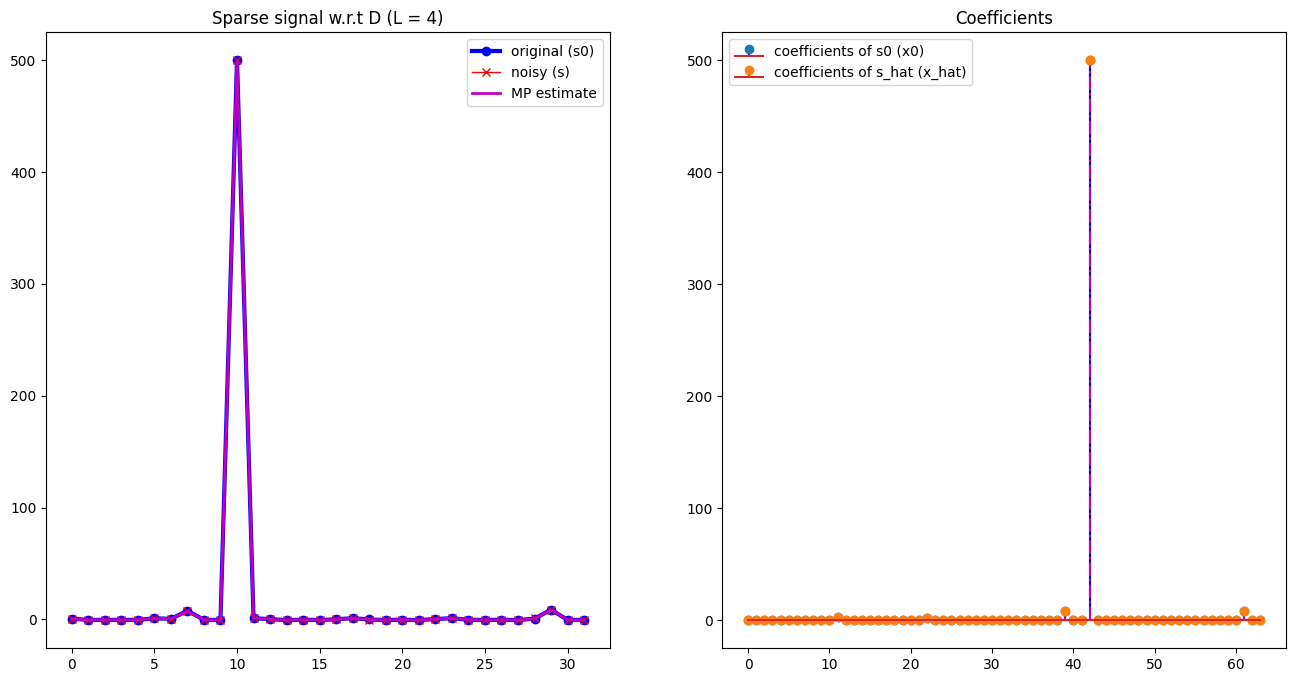

In [405]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(s0, 'b-o', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_OMP, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t D (L = {L:.0f})')
ax[0].legend(['original (s0)', 'noisy (s)', 'MP estimate'])

ax[1].stem(x0, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_OMP, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('Coefficients')
ax[1].legend(['coefficients of s0 (x0)', 'coefficients of s_hat (x_hat)'])

Least Squares Orthogonal Matching Pursuit
-----------------------------------------

Initialize all the variables, including the residual, namely the components of the signals that can not be represented (here the signal at the very beginning)

In [406]:
x_LSOMP = np.zeros(N)

# residual
r = s.copy()

# support set
omega = []

MINIMUM_NORM_RES = 0.1

LSOMP loop starts.

Stoppint criteria: continue until the sparsity of the representation reaches L

In [407]:
while len(omega) <= L :
    # SWEEP STEP: find the best column by solving the LS problem
    if len(omega) == 0:
        # at the first iteration perform the usual sweep step
        e = np.zeros(N)
        for j in range(N):
            zj = np.dot(D[:, j], r)
            e[j] = np.linalg.norm(r - (zj / np.linalg.norm(D[:, j])**2) * D[:, j])
        jStar = np.argmin(e)

    else:
        e = np.full(N, np.inf)
        # perform the sweep step by solving the LS problem
        for j in range(N):
            if j not in omega:
                test_omega = omega + [j]
                x_i = np.linalg.lstsq(D[:, test_omega], s, rcond=None)[0]
                e[j] = np.linalg.norm(s - D[:, test_omega] @ x_i)
        jStar = np.argmin(e)

    # UPDATE the support set with the jStar coefficient
    omega.append(jStar)
    # update the coefficients
    x_temp = np.linalg.lstsq(D[:, omega], s, rcond=None)[0]

    # update the residual
    r = s - D[:,omega] @ x_temp
x_OMP[omega] = x_temp


SYNTHESIS: reconstruct the signal, by inverting the transformation to reconstruct the signal

In [408]:
s_hat_LSOMP = D @ x_LSOMP

Show the result

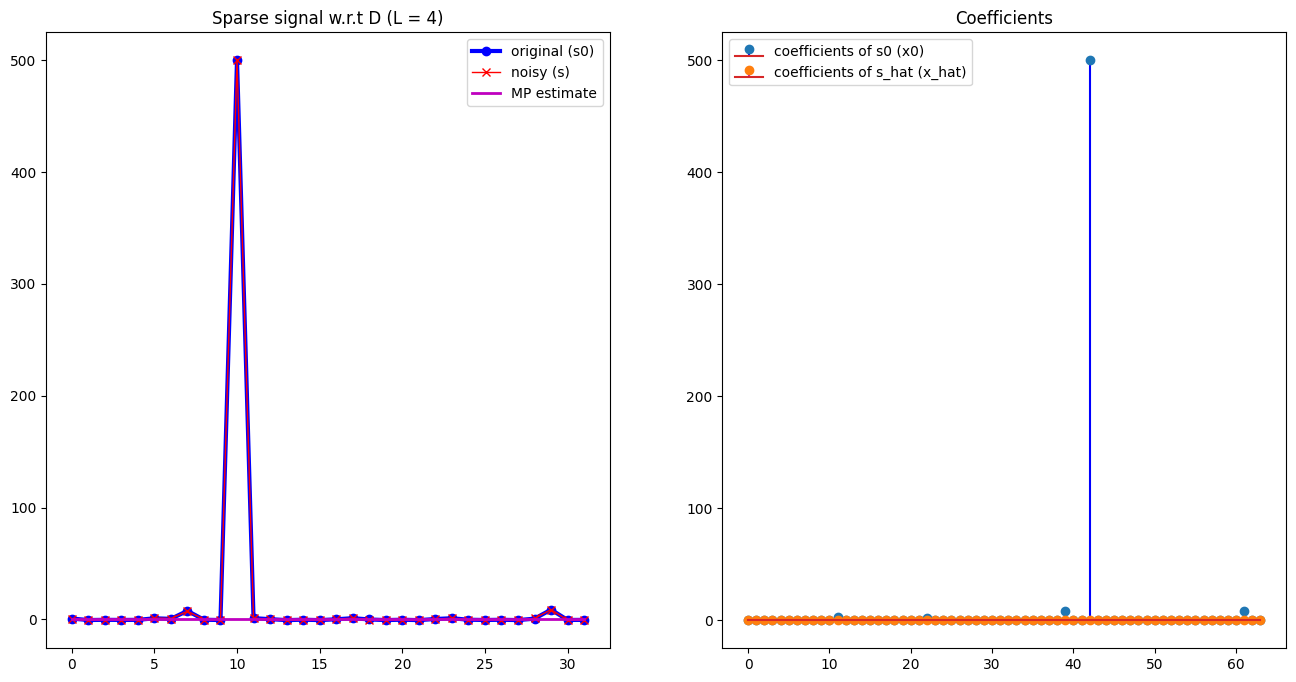

In [409]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(s0, 'b-o', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_LSOMP, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t D (L = {L:.0f})')
ax[0].legend(['original (s0)', 'noisy (s)', 'MP estimate'])

ax[1].stem(x0, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_LSOMP, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('Coefficients')
ax[1].legend(['coefficients of s0 (x0)', 'coefficients of s_hat (x_hat)'])